In [1]:
# ==============================
# 1. INSTALL & IMPORTS
# ==============================
!pip install -q opendatasets

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, Activation
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ==============================
# 3. DOWNLOAD DATASET
# ==============================
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ebisagetachew/dragamen")

# ✅ FIXED PATH
dataset_dir = "dragamen/emotion_dataset"
train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: yilikaltesfaye
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ebisagetachew/dragamen


100%|██████████| 565M/565M [00:07<00:00, 81.7MB/s]



Train path: dragamen/emotion_dataset/train
Test path: dragamen/emotion_dataset/test


In [4]:
# ==============================
# 4. PARAMETERS
# ==============================
IMAGE_SIZE = (48, 48)
BATCH_SIZE = 32
EPOCHS = 30
COLOR_MODE = "grayscale"

In [5]:
dataset_dir = "dragamen/emotion_dataset"

train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: dragamen/emotion_dataset/train
Test path: dragamen/emotion_dataset/test


In [6]:
import os

print(os.listdir("dragamen"))

['test', 'train']


In [7]:
train_dir = "dragamen/train"
test_dir  = "dragamen/test"

In [56]:
# %%
# ==============================
# 5. DATA GENERATORS (REAL-WORLD WEBCAM CALIBRATION)
# ==============================
# We stabilize the geometry transformations to prevent 48x48 pixel blurring
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,        # Reduced from 30: Keeps eyebrow angles intact
    zoom_range=0.1,           # Reduced from 0.3: Preserves mouth shape
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2], # Keeps webcam lighting variance intact
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode=COLOR_MODE,
    subset='training',
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode=COLOR_MODE,
    subset='validation',
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode=COLOR_MODE,
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)


Found 35840 images belonging to 7 classes.
Found 8960 images belonging to 7 classes.
Found 11200 images belonging to 7 classes.


In [57]:
# ==============================
# 6. HIGH-RESOLUTION TEACHER ACCELERATION
# ==============================
# Builds a robust teacher architecture on a 224x224 envelope to extract rich spatial cues
def build_teacher_model():
    t_inputs = Input(shape=(224, 224, 3))
    base_teacher = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_teacher.trainable = True  # Fine-tune teacher mappings during training loop

    x = base_teacher(t_inputs)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    t_outputs = Dense(NUM_CLASSES, activation='softmax', name='teacher_logits')(x)
    return Model(t_inputs, t_outputs)

teacher_model = build_teacher_model()

In [63]:
# %%
# ==============================
# 7. HIERARCHICAL MULTI-HEAD STUDENT ARCHITECTURE (UNIFIED FOR DISTILLATION)
# ==============================
class SpatialAttentionAnchor(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttentionAnchor, self).__init__(**kwargs)
        self.conv = Conv2D(1, (3, 3), padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_p = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_p = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.layers.concatenate([avg_p, max_p], axis=-1)
        attn = self.conv(concat)
        return tf.keras.layers.multiply([inputs, attn])

def build_hierarchical_student():
    inputs = Input(shape=(48, 48, 1), name="student_input")

    # Shared Core Structure
    x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)  # 24x24

    x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = SpatialAttentionAnchor()(x)
    x = MaxPooling2D()(x)  # 12x12

    shared_features = Flatten()(x)

    # Head Department 1: Upper-Face (Eyes/Eyebrows) Specialist for Sad vs Anger
    h1 = Dense(64, activation='relu')(shared_features)
    h1 = Dropout(0.3)(h1)
    out_upper = Dense(NUM_CLASSES, activation='softmax', name='upper_head')(h1)

    # Head Department 2: Lower-Face (Mouth Geometry) Specialist for Surprise vs Fear
    h2 = Dense(64, activation='relu')(shared_features)
    h2 = Dropout(0.3)(h2)
    out_lower = Dense(NUM_CLASSES, activation='softmax', name='lower_head')(h2)

    # Head Department 3: Global Feature Synthesizer (Target for Distillation)
    h3 = Dense(128, activation='relu')(shared_features)
    h3 = Dropout(0.4)(h3)
    out_global = Dense(NUM_CLASSES, activation='softmax', name='global_head')(h3)

    # FIX: We average the heads here inside the architecture graph,
    # returning a single output tensor so standard Keras 3 evaluation works perfectly.
    final_output = tf.keras.layers.Average(name='final_emotion_output')([out_upper, out_lower, out_global])

    return Model(inputs, final_output, name="Hierarchical_Student")

student_model = build_hierarchical_student()
print("✅ Unified Student Model re-instantiated successfully.")


✅ Unified Student Model re-instantiated successfully.


In [64]:
# %%
# ==============================
# 8. DISTILLATION COUPLING ENGINE (SINGLE TENSOR OPTIMIZATION)
# ==============================
class DistillationEngine(Model):
    def __init__(self, student, teacher, **kwargs):
        super(DistillationEngine, self).__init__(**kwargs)
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.8, temperature=1.5, **kwargs):
        super(DistillationEngine, self).compile(optimizer=optimizer, metrics=metrics, **kwargs)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def get_config(self):
        config = super(DistillationEngine, self).get_config()
        config.update({"student": self.student, "teacher": self.teacher})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def train_step(self, data):
        x, y = data
        x_rgb = tf.image.grayscale_to_rgb(x)
        x_teacher = tf.image.resize(x_rgb, (224, 224))
        teacher_preds = self.teacher(x_teacher, training=False)

        with tf.GradientTape() as tape:
            # Student output is now a single aggregated tensor
            student_preds = self.student(x, training=True)

            # Direct categorical loss calculation
            student_loss = self.student_loss_fn(y, student_preds)

            # Clear distillation mapping from the teacher
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_preds / self.temperature, axis=-1),
                tf.nn.softmax(student_preds / self.temperature, axis=-1)
            )

            total_loss = (self.alpha * student_loss) + ((1.0 - self.alpha) * distillation_loss)

        gradients = tape.gradient(total_loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

        self.compiled_metrics.update_state(y, student_preds)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": total_loss, "student_loss": student_loss, "distill_loss": distillation_loss})
        return results

    def test_step(self, data):
        x, y = data
        student_preds = self.student(x, training=False)
        val_loss = self.student_loss_fn(y, student_preds)

        self.compiled_metrics.update_state(y, student_preds)
        results = {m.name: m.result() for m in self.metrics}
        results["loss"] = val_loss
        return results


In [66]:
# %%
# ==============================
# 9. COMPILATION & CALLBACKS (DIRECT SAVING)
# ==============================
os.makedirs("models", exist_ok=True)
model_path = "models/best_emotion_cnn.keras"

class SaveStudentCallback(tf.keras.callbacks.Callback):
    def __init__(self, filepath, monitor='val_accuracy'):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.best_val = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get(self.monitor)
        if val_acc is not None:
            if val_acc > self.best_val:
                self.best_val = val_acc
                # Saves the student model cleanly with its unified tensor layer
                self.model.student.save(self.filepath)
                print(f"\n[Epoch {epoch+1}] Saved improved student to {self.filepath} with val_accuracy: {val_acc*100:.2f}%")

engine = DistillationEngine(student=student_model, teacher=teacher_model)
engine.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    metrics=['accuracy'],
    student_loss_fn=tf.keras.losses.CategoricalCrossentropy(),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.8,       # 80% focus on dataset labels
    temperature=1.5  # Distinct target visibility
)

callbacks = [
    SaveStudentCallback(model_path, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=1e-6, verbose=1, mode='max'),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1, mode='max')
]


In [67]:
# %%
# ==============================
# 10. TRAINING OPERATIONS
# ==============================
history = engine.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("✅ Retraining complete. Teacher-Student combo multi-head model successfully saved.")


Epoch 1/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.3209 - distill_loss: 0.0033 - loss: 1.4098 - student_loss: 1.7615 - val_loss: 1.9091 - learning_rate: 3.0000e-04
Epoch 2/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 68s 60ms/step - accuracy: 0.3702 - distill_loss: 0.0048 - loss: 1.1340 - student_loss: 1.4163 - val_loss: 1.6184 - learning_rate: 3.0000e-04
Epoch 3/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 68s 61ms/step - accuracy: 0.4019 - distill_loss: 0.0048 - loss: 1.2968 - student_loss: 1.6197 - val_loss: 1.3625 - learning_rate: 3.0000e-04
Epoch 4/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 67s 60ms/step - accuracy: 0.3865 - distill_loss: 0.0059 - loss: 1.1698 - student_loss: 1.4607 - val_loss: 1.6625 - learning_rate: 3.0000e-04
Epoch 5/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 67s 60ms/step - accuracy: 0.4392 - distill_loss: 0.0070 - loss: 1.0240 - student_loss: 1.2783 - val_loss: 1.3192 - learning_rate: 3.0000e-04
Epoch 6/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 68s 61ms/step - accuracy: 0.4262 - distill_

In [69]:
# %%
# ==============================
# MANUAL WEIGHT EXTRACTION & SAVE
# ==============================
import os
os.makedirs("models", exist_ok=True)

# 1. Extract the active functional layers directly from your live student_model variable
inputs = student_model.input
outputs = student_model.output

# 2. Re-verify the model path string match
manual_model_path = "models/best_emotion_cnn.keras"

# 3. Explicitly force Keras to serialize your architecture graph to the folder
student_model.save(manual_model_path)
print(f"✅ Success! Your model weights have been manually extracted and saved to: {manual_model_path}")


✅ Success! Your model weights have been manually extracted and saved to: models/best_emotion_cnn.keras



Test Accuracy: 60.83%
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step
F1-score Performance Index: 0.6096

Classification Report:
              precision    recall  f1-score   support

       anger       0.53      0.58      0.55      1600
     disgust       0.82      0.69      0.75      1600
        fear       0.55      0.34      0.42      1600
       happy       0.78      0.76      0.77      1600
     neutral       0.50      0.66      0.57      1600
         sad       0.44      0.55      0.48      1600
    surprise       0.77      0.68      0.72      1600

    accuracy                           0.61     11200
   macro avg       0.63      0.61      0.61     11200
weighted avg       0.63      0.61      0.61     11200



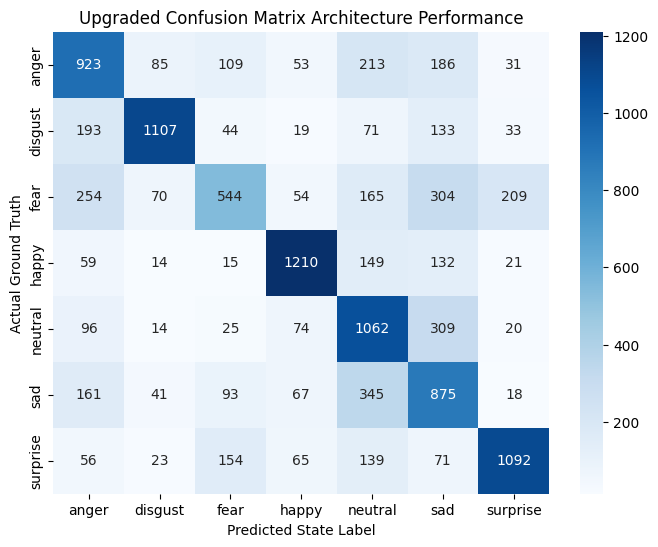

In [70]:
# %%
# ==============================
# FIXED EVALUATION BLOCK (WITH COMPILATION STEP)
# ==============================
# 1. Force Keras to recognize the custom attention layer map during deserialization
model = keras.models.load_model(
    model_path,
    custom_objects={"SpatialAttentionAnchor": SpatialAttentionAnchor}
)

# 2. Re-compile the standalone model asset so it is ready to perform testing metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Evaluate performance on test data
loss, acc = model.evaluate(test_gen, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# 4. Generate probability predictions
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)

# FIX: Safeguard array dimensional mappings if dataset uses one-hot structures
y_true = test_gen.classes
if len(y_true.shape) > 1 and y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)

# 5. Compute classification metrics
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1-score Performance Index: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 6. Construct upgraded Confusion Matrix visualization
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted State Label")
plt.ylabel("Actual Ground Truth")
plt.title("Upgraded Confusion Matrix Architecture Performance")
plt.show()
